In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, f1_score, classification_report

In [2]:
file_path = r""

business_raw = pd.read_excel(file_path, sheet_name="Empresa PROMESA")

In [3]:
business_raw.columns = (
    business_raw.columns
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

business = business_raw.rename(columns={
    "Fecha": "date",
    "EMPRESA": "business",
    "SUBSECTOR": "subsector",
    "TOTAL [kg]": "total_kg"
})

business["date"] = pd.to_datetime(business["date"], errors="coerce")
business["month"] = business["date"].dt.to_period("M").dt.to_timestamp()
business["total_kg"] = pd.to_numeric(business["total_kg"], errors="coerce")

monthly_business = (
    business
    .dropna(subset=["business", "month"])
    .groupby(["business", "month"], as_index=False)
    .agg(total_kg=("total_kg", "sum"))
)

print("Total businesses:", monthly_business["business"].nunique())
print("Monthly records:", len(monthly_business))
print("Date range:", monthly_business["month"].min(), "to", monthly_business["month"].max())
monthly_business["total_kg"].describe()

Total businesses: 56
Monthly records: 987
Date range: 2023-01-01 00:00:00 to 2025-09-01 00:00:00


count      987.000000
mean       609.902381
std        930.092160
min          0.000000
25%         80.200000
50%        238.100000
75%        821.220000
max      11820.260000
Name: total_kg, dtype: float64

In [4]:
months_per_business = (
    monthly_business
    .groupby("business")["month"]
    .nunique()
    .sort_values(ascending=False)
)

print("Total num of business:", monthly_business["business"].nunique())
print("Avg months:", round(months_per_business.mean(), 2))
print("Median months:", round(months_per_business.median(), 2))
print("Min months:", months_per_business.min())
print("Max months:", months_per_business.max())

print("\nMonthly Values")
print("Minimum:", round(monthly_business["total_kg"].min(), 2))
print("Median:", round(monthly_business["total_kg"].median(), 2))
print("Average:", round(monthly_business["total_kg"].mean(), 2))
print("Maximum:", round(monthly_business["total_kg"].max(), 2))

print("\nQuartiles")
print(monthly_business["total_kg"].quantile([0.25, 0.5, 0.75]))

Total num of business: 56
Avg months: 17.62
Median months: 16.5
Min months: 1
Max months: 33

Monthly Values
Minimum: 0.0
Median: 238.1
Average: 609.9
Maximum: 11820.26

Quartiles
0.25     80.20
0.50    238.10
0.75    821.22
Name: total_kg, dtype: float64


# Slide 1 - Findings

- **56 businesses** in total; **47** have sufficient monthly records.

- Data spans **Jan 2023–Sep 2025**.

- Each business has about **18 months** of data on average.

- Long-term forecasting is difficult due to limited records and high-volume outliers.

# Slide 2 - Business Collection Over Time

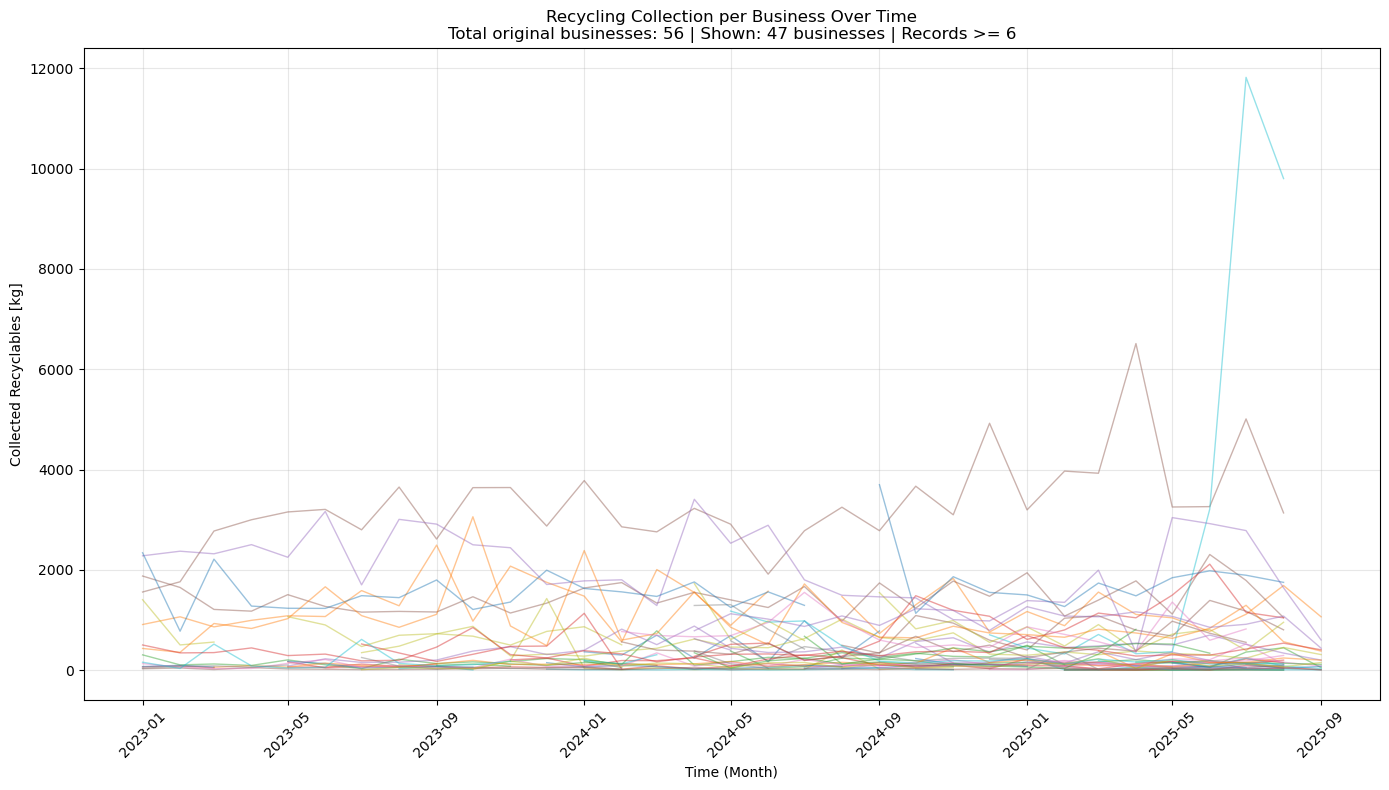

In [5]:
record_threshold = 6

valid_businesses = months_per_business[months_per_business >= record_threshold].index

plot_data = monthly_business[monthly_business["business"].isin(valid_businesses)].copy()

pivot_business = (
    plot_data
    .pivot(index="month", columns="business", values="total_kg")
    .sort_index()
)

plt.figure(figsize=(14, 8))

for col in pivot_business.columns:
    plt.plot(pivot_business.index, pivot_business[col], alpha=0.45, linewidth=1)

plt.title(
    f"Recycling Collection per Business Over Time\n"
    f"Total original businesses: {monthly_business['business'].nunique()} | "
    f"Shown: {len(valid_businesses)} businesses | Records >= {record_threshold}"
)
plt.xlabel("Time (Month)")
plt.ylabel("Collected Recyclables [kg]")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
record_threshold = 6

total_businesses = monthly_business["business"].nunique()
valid_businesses = months_per_business[months_per_business >= record_threshold].index
num_valid_businesses = len(valid_businesses)

start_month = monthly_business["month"].min()
end_month = monthly_business["month"].max()

avg_months = months_per_business.mean()

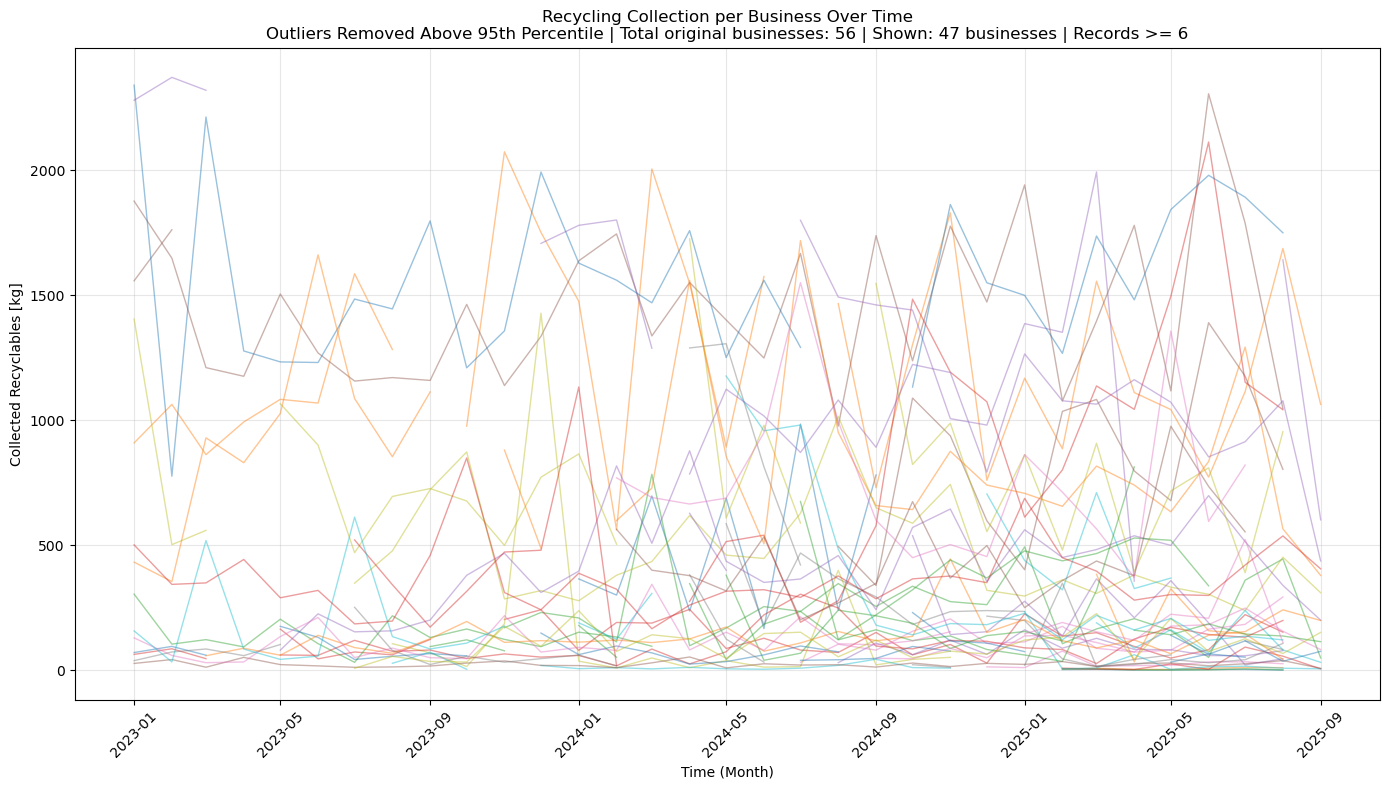

95th percentile outlier threshold: 2379.69


In [7]:
record_threshold = 6
valid_businesses = months_per_business[months_per_business >= record_threshold].index

# Remove extreme monthly outliers for visualization only
outlier_threshold = monthly_business["total_kg"].quantile(0.95)

plot_data_clean = monthly_business[
    (monthly_business["business"].isin(valid_businesses)) &
    (monthly_business["total_kg"] <= outlier_threshold)
].copy()

pivot_clean = (
    plot_data_clean
    .pivot(index="month", columns="business", values="total_kg")
    .sort_index()
)

plt.figure(figsize=(14, 8))

for col in pivot_clean.columns:
    plt.plot(pivot_clean.index, pivot_clean[col], alpha=0.45, linewidth=1)

plt.title(
    f"Recycling Collection per Business Over Time\n"
    f"Outliers Removed Above 95th Percentile | "
    f"Total original businesses: {total_businesses} | "
    f"Shown: {num_valid_businesses} businesses | Records >= {record_threshold}"
)
plt.xlabel("Time (Month)")
plt.ylabel("Collected Recyclables [kg]")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("95th percentile outlier threshold:", round(outlier_threshold, 2))

In [8]:
def create_sliding_window_dataset(df, entity_col="business", value_col="total_kg", window_size=6):
    rows = []
    
    for entity_name, group in df.sort_values([entity_col, "month"]).groupby(entity_col):
        values = group[value_col].values
        
        if len(values) >= window_size + 1:
            for i in range(len(values) - window_size):
                row = {entity_col: entity_name}
                
                for j in range(window_size):
                    row[f"M{j+1}"] = values[i + j]
                
                row["target"] = values[i + window_size]
                rows.append(row)
    
    return pd.DataFrame(rows)

# Use businesses with enough monthly records
business_model_data = monthly_business[
    monthly_business["business"].isin(valid_businesses)
].copy()

business_reg_6 = create_sliding_window_dataset(
    business_model_data,
    entity_col="business",
    value_col="total_kg",
    window_size=6
)

business_reg_3 = create_sliding_window_dataset(
    business_model_data,
    entity_col="business",
    value_col="total_kg",
    window_size=3
)

# Slide 3 - Linear Regression
- Created a sliding-window dataset using **six consecutive months** as predictors and the **seventh month** as the target.

- Used **business recycling totals in kg** from the `Empresa PROMESA` dataset.

- The final regression dataset contains **684 rows** across **45 businesses**.

- The linear regression model achieved **R² = 0.853**, meaning prior monthly recycling volumes explain about **85.3%** of the variation in Month 7 collection weight.

- The actual vs. predicted plot shows the model captures the overall trend well, but very high-volume business outliers are harder to predict accurately.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = business_reg_6[[f"M{i}" for i in range(1, 7)]]
y = business_reg_6["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

linear_model_6 = LinearRegression()
linear_model_6.fit(X_train, y_train)

y_pred = linear_model_6.predict(X_test)

r2_6 = r2_score(y_test, y_pred)

print("Linear Regression on Business Recycling Data")
print("Rows:", len(business_reg_6))
print("Businesses:", business_reg_6["business"].nunique())
print("R²:", round(r2_6, 4))

Linear Regression on Business Recycling Data
Rows: 684
Businesses: 45
R²: 0.8526


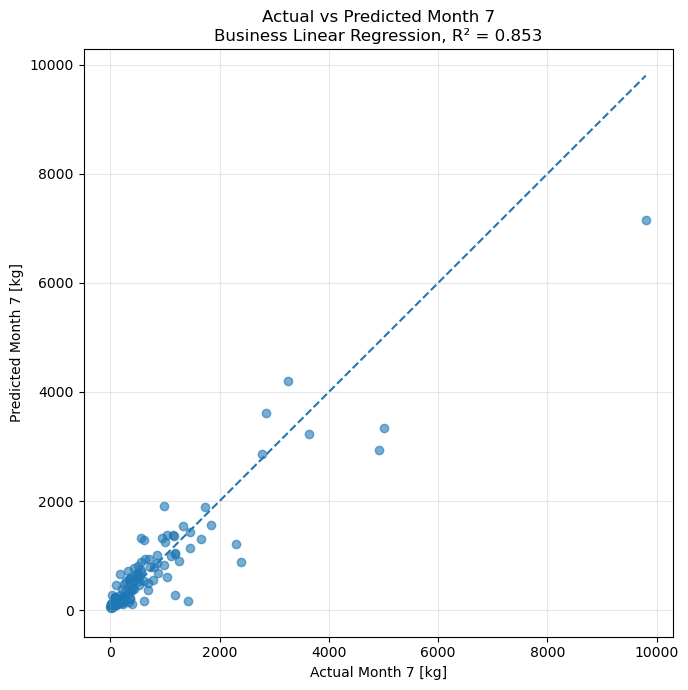

In [10]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title(f"Actual vs Predicted Month 7\nBusiness Linear Regression, R² = {r2_6:.3f}")
plt.xlabel("Actual Month 7 [kg]")
plt.ylabel("Predicted Month 7 [kg]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
business_reg_6.head(10)

,business,M1,M2,M3,M4,M5,M6,target
0,AMEX,364.72,299.96,696.46,236.30,687.78,165.91,984.10
1,AMEX,299.96,696.46,236.30,687.78,165.91,984.10,239.68
2,AMEX,696.46,236.30,687.78,165.91,984.10,239.68,780.22
3,Basalto,908.60,1062.70,861.80,992.40,1083.00,1068.00,1585.50
4,Basalto,1062.70,861.80,992.40,1083.00,1068.00,1585.50,1282.50
5,Basalto,861.80,992.40,1083.00,1068.00,1585.50,1282.50,2492.60
6,Basalto,992.40,1083.00,1068.00,1585.50,1282.50,2492.60,975.60
7,Basalto,1083.00,1068.00,1585.50,1282.50,2492.60,975.60,2073.10
8,Basalto,1068.00,1585.50,1282.50,2492.60,975.60,2073.10,1750.50
9,Basalto,1585.50,1282.50,2492.60,975.60,2073.10,1750.50,1475.10


# Slide 4 - Classification

- Business recycling values were discretized into tertiles: **Low**, **Medium**, and **High** using `pd.qcut()`.

- The distribution is right-skewed — most businesses recycle at moderate monthly volumes, while a small number of businesses create high-volume outliers.

- Three classification models were compared: **Softmax Regression**, **XGBoost**, and **Random Forest**.

- The winner, **Softmax Regression**, achieved the highest overall performance with an accuracy of around **0.737** and F1 score around **0.737**.

- Earlier monthly recycling patterns provide predictive value, but boundary overlap between Medium and High/Low categories may still affect classification accuracy.

In [12]:
business_class = business_reg_6.copy()

business_class["target_class"] = pd.qcut(
    business_class["target"],
    q=3,
    labels=["Low", "Medium", "High"]
)

class_counts = business_class["target_class"].value_counts()

bins = pd.qcut(
    business_class["target"],
    q=3,
    retbins=True
)[1]

print("Target class distribution:")
print(class_counts)

print("\nClassification bins:")
print("Low: <=", round(bins[1], 2), "kg")
print("Medium:", round(bins[1], 2), "to", round(bins[2], 2), "kg")
print("High: >", round(bins[2], 2), "kg")

Target class distribution:
target_class
Low       228
Medium    228
High      228
Name: count, dtype: int64

Classification bins:
Low: <= 131.85 kg
Medium: 131.85 to 598.47 kg
High: > 598.47 kg


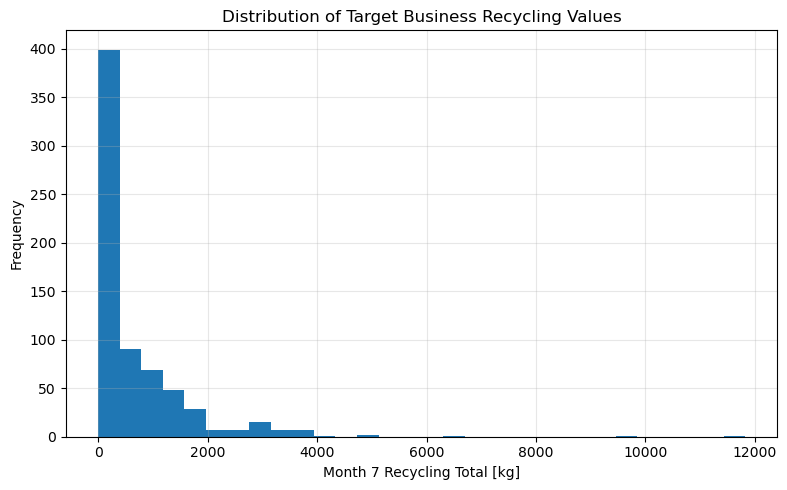

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(business_class["target"], bins=30)

plt.title("Distribution of Target Business Recycling Values")
plt.xlabel("Month 7 Recycling Total [kg]")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Prepare X and y
X = business_class[[f"M{i}" for i in range(1, 7)]]
y = business_class["target_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_results = []

# -----------------------------
# 1. Softmax Regression
# -----------------------------

softmax_model = LogisticRegression(max_iter=5000)
softmax_model.fit(X_train, y_train)
softmax_pred = softmax_model.predict(X_test)

model_results.append({
    "Model": "Softmax Regression",
    "Accuracy": accuracy_score(y_test, softmax_pred),
    "F1 Score": f1_score(y_test, softmax_pred, average="weighted")
})

# -----------------------------
# 2. Random Forest
# -----------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

model_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred, average="weighted")
})

# -----------------------------
# 3. XGBoost
# -----------------------------

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train_encoded)

xgb_pred_encoded = xgb_model.predict(X_test)
xgb_pred = label_encoder.inverse_transform(xgb_pred_encoded)

model_results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "F1 Score": f1_score(y_test, xgb_pred, average="weighted")
})

# Final comparison table
classification_results = pd.DataFrame(model_results)

classification_results

,Model,Accuracy,F1 Score
0,Softmax Regression,0.737226,0.736519
1,Random Forest,0.715328,0.716333
2,XGBoost,0.708029,0.709487


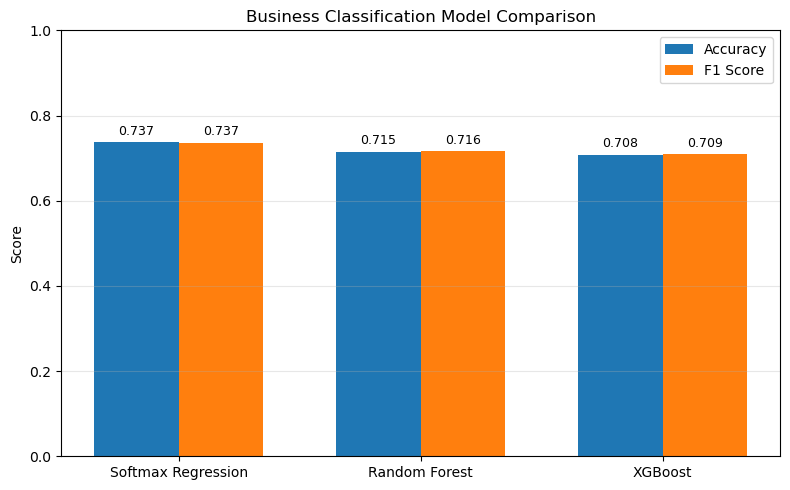

In [15]:
x = np.arange(len(classification_results["Model"]))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    classification_results["Accuracy"],
    width,
    label="Accuracy"
)

bars2 = plt.bar(
    x + width/2,
    classification_results["F1 Score"],
    width,
    label="F1 Score"
)

# Add numbers above bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(x, classification_results["Model"])
plt.ylabel("Score")
plt.title("Business Classification Model Comparison")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score

# Identify best model based on F1 Score
best_model_name = classification_results.sort_values("F1 Score", ascending=False).iloc[0]["Model"]

if best_model_name == "Softmax Regression":
    best_pred = softmax_pred
elif best_model_name == "Random Forest":
    best_pred = rf_pred
else:
    best_pred = xgb_pred

print("Best model:", best_model_name)

# Overall metrics
overall_precision = precision_score(y_test, best_pred, average="weighted")
overall_recall = recall_score(y_test, best_pred, average="weighted")
overall_f1 = f1_score(y_test, best_pred, average="weighted")
overall_accuracy = accuracy_score(y_test, best_pred)

print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1: {overall_f1:.4f}")
print(f"Accuracy: {overall_accuracy:.4f}")

# Classification report table
report_dict = classification_report(y_test, best_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Round for slide readability
report_df = report_df.round(2)

report_df

Best model: Softmax Regression
Precision: 0.7367
Recall: 0.7372
F1: 0.7365
Accuracy: 0.7372


,precision,recall,f1-score,support
High,0.81,0.78,0.80,45.00
Low,0.78,0.83,0.80,46.00
Medium,0.62,0.61,0.62,46.00
accuracy,0.74,0.74,0.74,0.74
macro avg,0.74,0.74,0.74,137.00
weighted avg,0.74,0.74,0.74,137.00


# Appendix Slide 1

In [17]:
record_threshold = 6

months_per_business = (
    monthly_business
    .groupby("business")["month"]
    .nunique()
    .sort_values(ascending=False)
)

total_businesses = monthly_business["business"].nunique()
valid_businesses = months_per_business[months_per_business >= record_threshold].index
num_valid_businesses = len(valid_businesses)

business_summary = monthly_business.groupby("business").agg(
    MONTHS_OF_DATA=("month", "nunique"),
    MIN_MONTHLY_KG=("total_kg", "min"),
    MAX_MONTHLY_KG=("total_kg", "max"),
    AVG_MONTHLY_KG=("total_kg", "mean")
).reset_index()

business_summary["RANGE_MONTHLY_KG"] = (
    business_summary["MAX_MONTHLY_KG"] - business_summary["MIN_MONTHLY_KG"]
)

print("Descriptive Stats (Business)")
print("Total num of business:", total_businesses)

print("\nAvg, Med, Min and Max the number of months that data have been collected")
print("Avg:", round(business_summary["MONTHS_OF_DATA"].mean(), 2))
print("Median:", round(business_summary["MONTHS_OF_DATA"].median(), 2))
print("Min:", business_summary["MONTHS_OF_DATA"].min())
print("Max:", business_summary["MONTHS_OF_DATA"].max())

print("\nMonthly Values")
print("Minimum:", round(monthly_business["total_kg"].min(), 2), "kg")
print("Median:", round(monthly_business["total_kg"].median(), 2), "kg")
print("Average:", round(monthly_business["total_kg"].mean(), 2), "kg")
print("Maximum:", round(monthly_business["total_kg"].max(), 2), "kg")

print("\nQuartiles")
print("Q1:", round(monthly_business["total_kg"].quantile(0.25), 2), "kg")
print("Q2 / Median:", round(monthly_business["total_kg"].quantile(0.50), 2), "kg")
print("Q3:", round(monthly_business["total_kg"].quantile(0.75), 2), "kg")

# Show top businesses by monthly range
business_summary.sort_values("RANGE_MONTHLY_KG", ascending=False).head(10)

Descriptive Stats (Business)
Total num of business: 56

Avg, Med, Min and Max the number of months that data have been collected
Avg: 17.62
Median: 16.5
Min: 1
Max: 33

Monthly Values
Minimum: 0.0 kg
Median: 238.1 kg
Average: 609.9 kg
Maximum: 11820.26 kg

Quartiles
Q1: 80.2 kg
Q2 / Median: 238.1 kg
Q3: 821.22 kg


,business,MONTHS_OF_DATA,MIN_MONTHLY_KG,MAX_MONTHLY_KG,AVG_MONTHLY_KG,RANGE_MONTHLY_KG
36,Mapfre,9,321.0,11820.26,3077.801111,11499.26
19,Essilor,32,1557.0,6511.80,3276.585938,4954.80
55,Walmart,2,540.4,5015.55,2777.975000,4475.15
42,PUJOL,33,356.0,3406.02,2032.924545,3050.02
48,San Martín,31,775.5,3697.40,1630.667742,2921.90
49,Servibev,33,354.0,3057.50,955.751515,2703.50
39,PFIZER,4,0.0,2463.00,691.575000,2463.00
41,PUERTAS MERIK,25,18.6,2112.20,758.644000,2093.60
2,Basalto,32,561.0,2492.60,1270.981875,1931.60
22,Grisi Amores,20,8.4,1492.50,209.886500,1484.10


# Appendix Slide 2

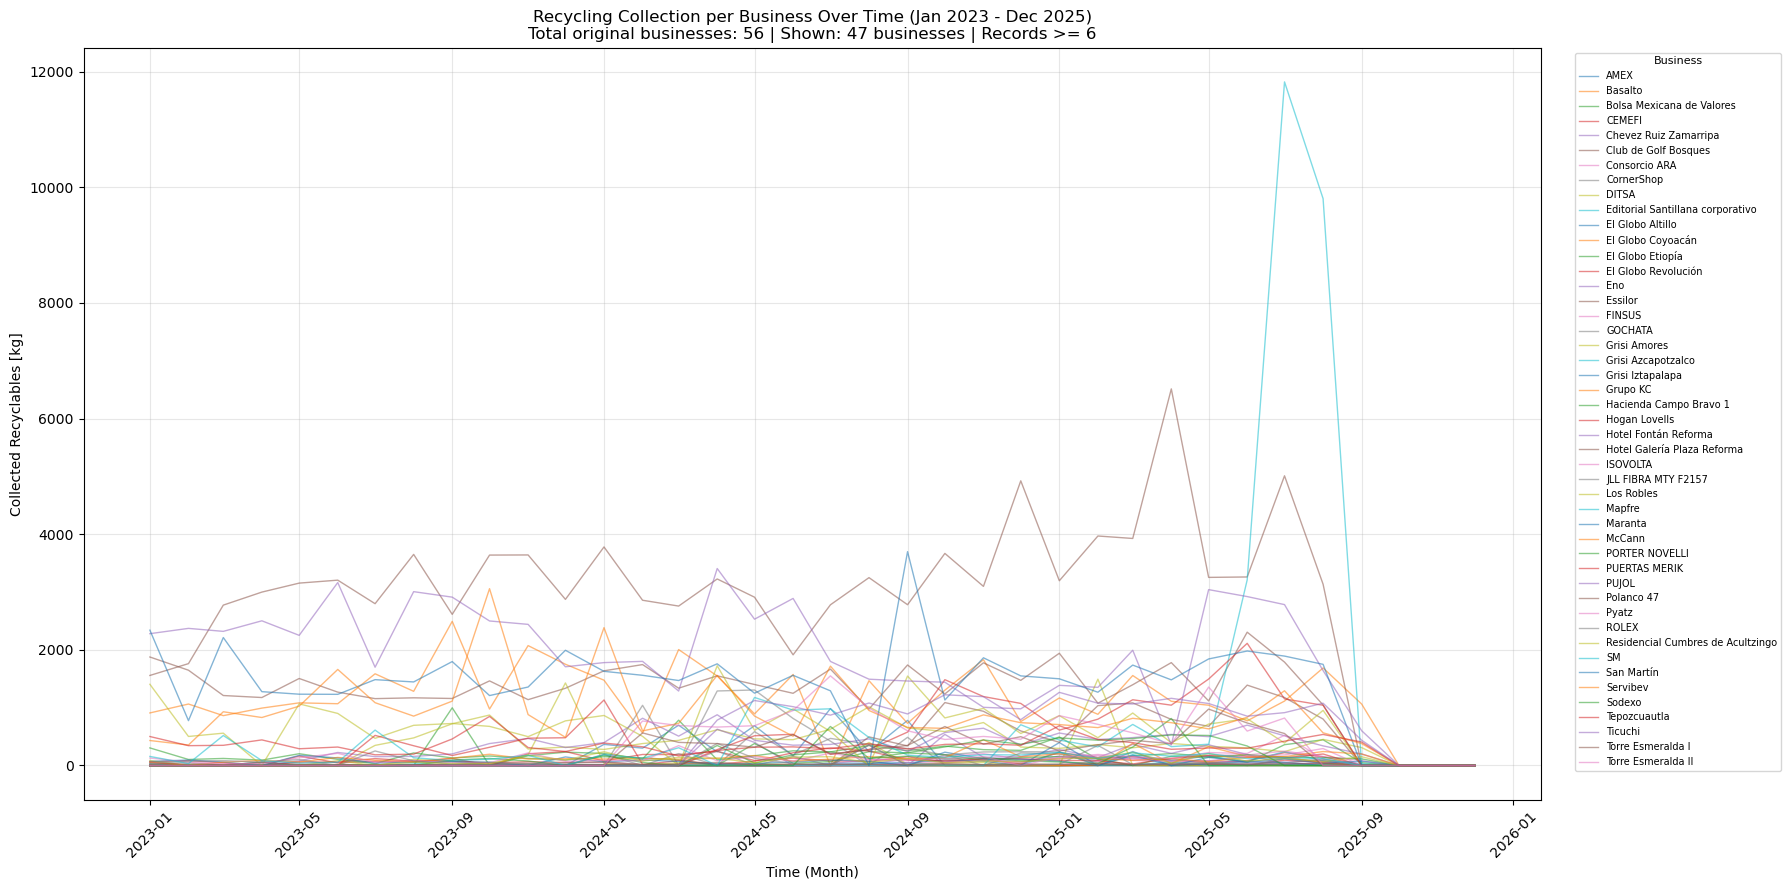

In [18]:
#legend
full_month_range = pd.date_range("2023-01-01", "2025-12-01", freq="MS")

plot_full = monthly_business[
    monthly_business["business"].isin(valid_businesses)
].copy()

pivot_full = (
    plot_full
    .pivot(index="month", columns="business", values="total_kg")
    .reindex(full_month_range)
)

# Missing months become -1 only for raw missing-value plot
pivot_full = pivot_full.fillna(-1)

plt.figure(figsize=(18, 9))

for col in pivot_full.columns:
    plt.plot(
        pivot_full.index,
        pivot_full[col],
        alpha=0.55,
        linewidth=1,
        label=col
    )

plt.title(
    f"Recycling Collection per Business Over Time (Jan 2023 - Dec 2025)\n"
    f"Total original businesses: {total_businesses} | "
    f"Shown: {num_valid_businesses} businesses | Records >= {record_threshold}"
)
plt.xlabel("Time (Month)")
plt.ylabel("Collected Recyclables [kg]")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Legend outside the chart
plt.legend(
    title="Business",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=7,
    title_fontsize=8,
    ncol=1
)

plt.tight_layout()
plt.show()

# Appendix Slide 3

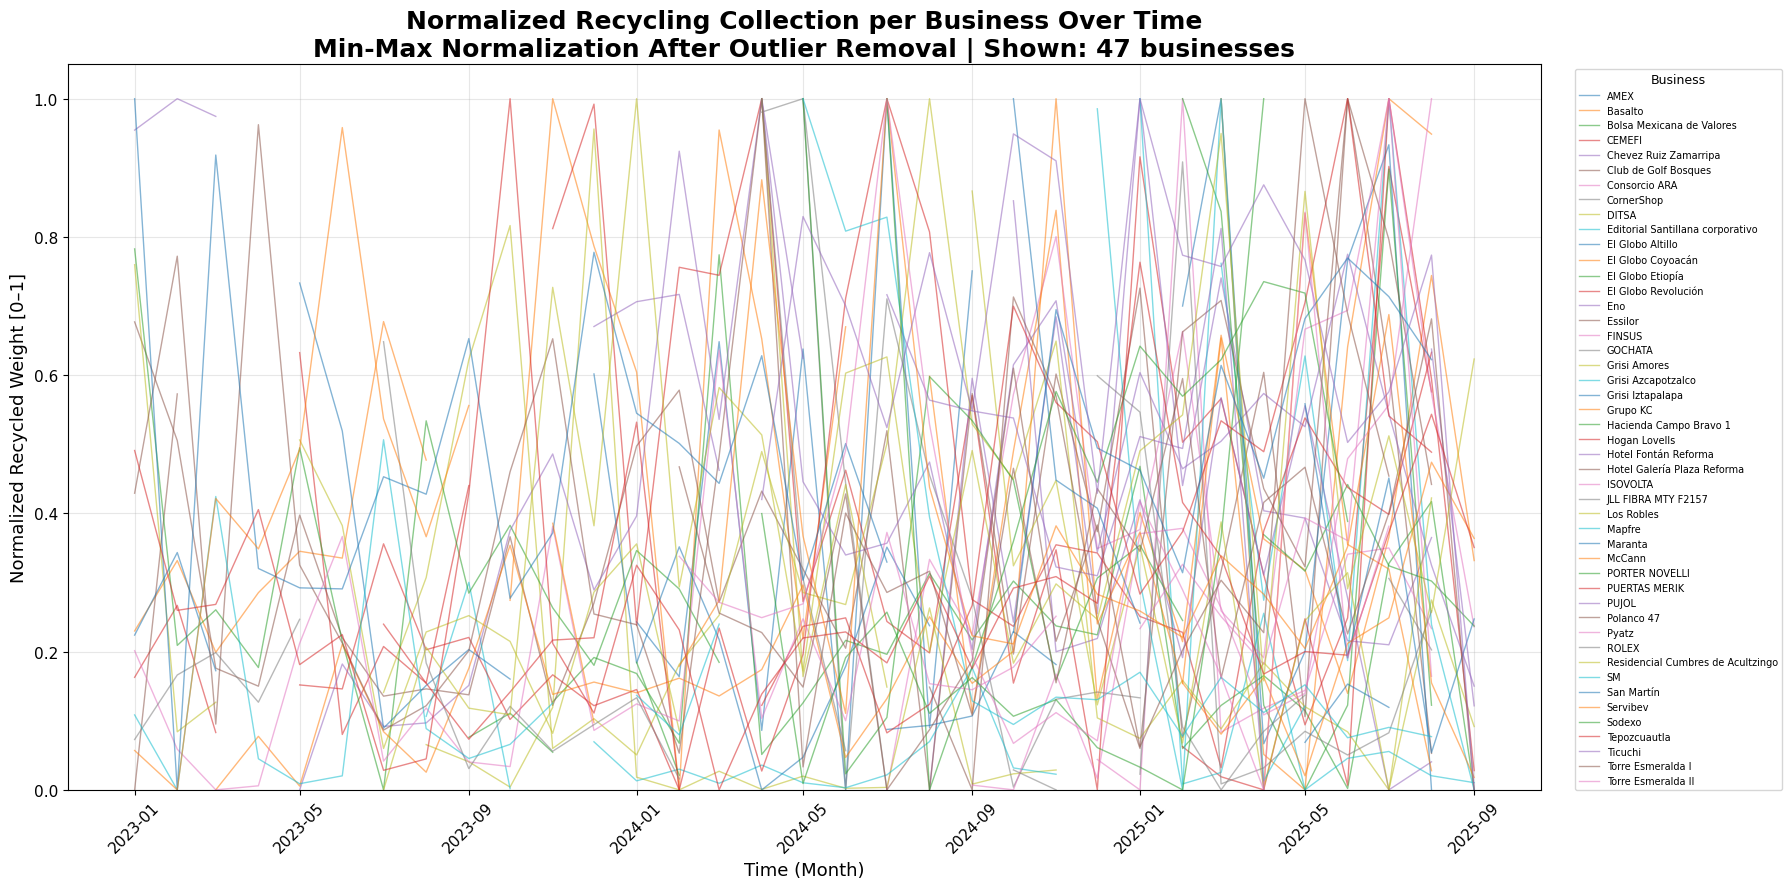

Outlier threshold removed before normalization: 2379.69


In [19]:
outlier_threshold = monthly_business["total_kg"].quantile(0.95)

norm_data = monthly_business[
    (monthly_business["business"].isin(valid_businesses)) &
    (monthly_business["total_kg"] <= outlier_threshold)
].copy()

# Full month range for consistent x-axis
full_month_range = pd.date_range("2023-01-01", "2025-12-01", freq="MS")

# Pivot: rows = months, columns = businesses
pivot_norm_raw = (
    norm_data
    .pivot(index="month", columns="business", values="total_kg")
    .reindex(full_month_range)
)

# Min-max normalize each business separately
pivot_norm = pivot_norm_raw.copy()

for col in pivot_norm.columns:
    valid_values = pivot_norm[col].dropna()
    
    if len(valid_values) == 0:
        continue
    
    min_val = valid_values.min()
    max_val = valid_values.max()
    
    if max_val == min_val:
        # If a business has the same value every month, set observed months to 0
        pivot_norm[col] = pivot_norm[col].apply(lambda x: 0 if pd.notna(x) else np.nan)
    else:
        pivot_norm[col] = (pivot_norm[col] - min_val) / (max_val - min_val)

# Important:
# Do NOT fill missing months with -1 here.
# Keep missing months as NaN so the chart stays 0-1.

plt.figure(figsize=(18, 9))

for col in pivot_norm.columns:
    plt.plot(
        pivot_norm.index,
        pivot_norm[col],
        alpha=0.55,
        linewidth=1,
        label=col
    )

plt.title(
    f"Normalized Recycling Collection per Business Over Time\n"
    f"Min-Max Normalization After Outlier Removal | "
    f"Shown: {num_valid_businesses} businesses",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Time (Month)", fontsize=13)
plt.ylabel("Normalized Recycled Weight [0–1]", fontsize=13)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3)

# Legend outside the plot
plt.legend(
    title="Business",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=7,
    title_fontsize=9,
    ncol=1
)

plt.tight_layout()
plt.show()

print("Outlier threshold removed before normalization:", round(outlier_threshold, 2))